# Unsourced Sequences in the _Heliand_

I have produced a hitherto nonpublic index of Bible verses reflected in _Heliand_ verses (i.e. halflines), and I am working on similar indices for other known sources.

The present notebook evaluates the scriptural index for notable gaps and looks for patterns.

__TODO:__ Currently working on the assumption that every halfline has content, including e.g. 2b and the four `x` halflines. Consider whether to rethink that.

## Indexing Principles

My index of Bible verses implements the following principles:

- The closest matching biblical (usually gospel) verse is listed as a source for a given halfline of the _Heliand_ if some part of the _Heliand_ verse may be said to have been translated from that Bible verse. Notably excluded from this definition are summaries, inferences, and augmentative variation. Equivalent variation is included, but "allaro barno bezt" is usually treated as augmentative. There is a substantial grey area here, as most verses contain two content words, one of which may be equivalent variation ("barna") while the other adds information ("bezt").
- If there is a single closest matching Bible verse, it is given as the first match for a halfline, but any verses that may be said to match that part of the narrative in the other gospels, or elsewhere in the same gospel, follow in parentheses, with comma delimiters. Such subsequent references say more about Bible-internal relationships than about their connection to the _Heliand_, but listing them under _Heliand_ halfline keys makes them relevant to the target text as background.
- Very occasionally, two (typically subsequent) Bible verses are considered to contribute to the halfline, in which case these are the first two entries, both without parentheses.
- I have typically followed the lead of the Codex Fuldensis witness to Tatian, as annotated by Sievers, to determine which gospel account was used for a given _Heliand_ passage. I have typically verified that Sievers was right. I have also felt free to diverge from Sievers by selecting the closest gospel match myself, and ranking subsequent parenthetical references by relative closeness where possible. Where multiple gospel accounts have seemed equally close to a _Heliand_ turn of phrase, I have often followed Sievers and/or defaulted to Matthew as the immediate or primary source, which often comes down to the same thing.
- In some cases, an entry consists entirely of parenthetical and thus distant matches.
- If a _Heliand_ verse departs from (i.e. innovates on) the narrative supplied by a Bible verse recorded as a nonparenthetical reference, that reference is followed by an asterisk. If subsequent, parenthetical references likewise lack the particular _Heliand_ angle, as they should, these too will have asterisks.
- In the case of _Heliand_ 5720b–5775b specifically, the asterisk means that the multitude which in Luke is said to accuse Christ is here conflated with Herod, as it then says they hope to see miracles, which is what Luke attributes to Herod.
- I may in future add a marker to "unsourced" _Heliand_ halflines whose content may be inferred from gospel content without counting as the direct translation of individual Bible verses.
- I may in future add a marker to Bible verses apparently used for _Heliand_ verses where Codex Fuldensis lacks these Bible verses.

In [1]:
import re,json
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# This JSON tells us the starting verse of each fitt, so we can label our data
# by fitt and look for patterns around fitt boundaries:
with open('../heliand-fitts.json') as json_file:
    fitts_index = json.load(json_file)

# This nonpublic file is not (at present) standard TSV:
# I use extra tabs to maintain visually distinct columns.
with open('../gospel-index.tsv') as f:
    xrefs_lines = f.read().splitlines()

xrefs = dict()
for line in xrefs_lines:
    rubble = re.split(r"\t+", line, maxsplit=1)
    if len(rubble) == 2:
        xrefs[rubble[0]] = rubble[1]
    else:
        xrefs[rubble[0]] = None

In [ ]:
# Identify all sequences of biblically unsourced halflines:
def gap_index():
    gaps = []
    active_gap = False
    for k,v in xrefs.items():
        if active_gap == False and v is None:
            gaps.append([k])
            active_gap = True
        elif active_gap == True and v is None:
            gaps[-1].append(k)
        else:
            active_gap = False
    return gaps

# Translate gap_index() data into a list of ranges and lengths
def gap_lengths(gaps):
    lengths = []
    #gaps = sorted(gaps, key=len, reverse=True)
    for gap in gaps:
        data = (gap[0] + '–' + gap[-1], len(gap))
        lengths.append(data)
    return lengths

# Helper function for identify_fitt():
def nearest_preceding_value(line, candidates):
    scores = [line-candidate for candidate in candidates if line-candidate > -1]
    winning_index = scores.index(min(scores))
    return candidates[winning_index]

# Identify the fitt for a given halfline:
def identify_fitt(verse):
    inverse = {v: k for k, v in fitts_index.items()}
    if verse in inverse:
        return inverse[verse]
    else:
        line = int(verse.rstrip('abx'))
        if verse[-1] == 'a':
            line -= 1
        intverse = {int(k.rstrip('abx')): v for k,v in inverse.items()}
        return intverse[nearest_preceding_value(line, list(intverse.keys()))]

# Return the fitt or fitt range for a range of halflines like "3586b–3670b":
def identify_fitts(data):
    values = data.split('–')
    x = identify_fitt(values[0])
    y = identify_fitt(values[1])
    if x == y:
        return 'fitt ' + x
    else:
        return 'fitts ' + x + '–' + y

def prev_verse(verse):
    if verse[-2:] == 'xa':
        return str(int(verse[:-2])-1) + 'b'
    elif verse[-1] == 'b':
        return verse.replace('b', 'a')
    else:
        return str(int(verse[:-1])-1) + 'b'
    
def next_verse(verse):
    if verse[-2:] == 'xb':
        return str(int(verse[:-2])+1) + 'a'
    elif verse[-1] == 'a':
        return verse.replace('a', 'b')
    else:
        return str(int(verse[:-1])+1) + 'a'

def get_frays():
    frays = {
        'start': dict(),
        'end': dict()
    }
    for k,v in fitts_index.items():
        start_fray = 0
        end_fray = 0
        current_verse = fitts_index[k]
        if k != '71':
            next_fitt_start = fitts_index[str(int(k)+1)]
        else:
            next_fitt_start = None
        if k != 1:
            prev_fitt_end = prev_verse(fitts_index[k])
        else:
            prev_fitt_end = None
        while not(current_verse == next_fitt_start) and xrefs[current_verse] == None:
            start_fray += 1
            current_verse = next_verse(current_verse)
        frays['start'][k] = start_fray
        if k == '71':
            current_verse = '5982b'
        else:
            current_verse = prev_verse(fitts_index[str(int(k)+1)])
        while not(current_verse == prev_fitt_end) and xrefs[current_verse] == None:
            end_fray += 1
            current_verse = prev_verse(current_verse)
        frays['end'][k] = end_fray
    return frays

In [4]:
gaps = gap_index()
lengths = gap_lengths(gaps)
df = pd.DataFrame(lengths, columns=['Range', 'Length in halflines'])
df_long_gaps = df[df['Length in halflines'] > 19]#.sort_values(by='Length in halflines', ascending=False)

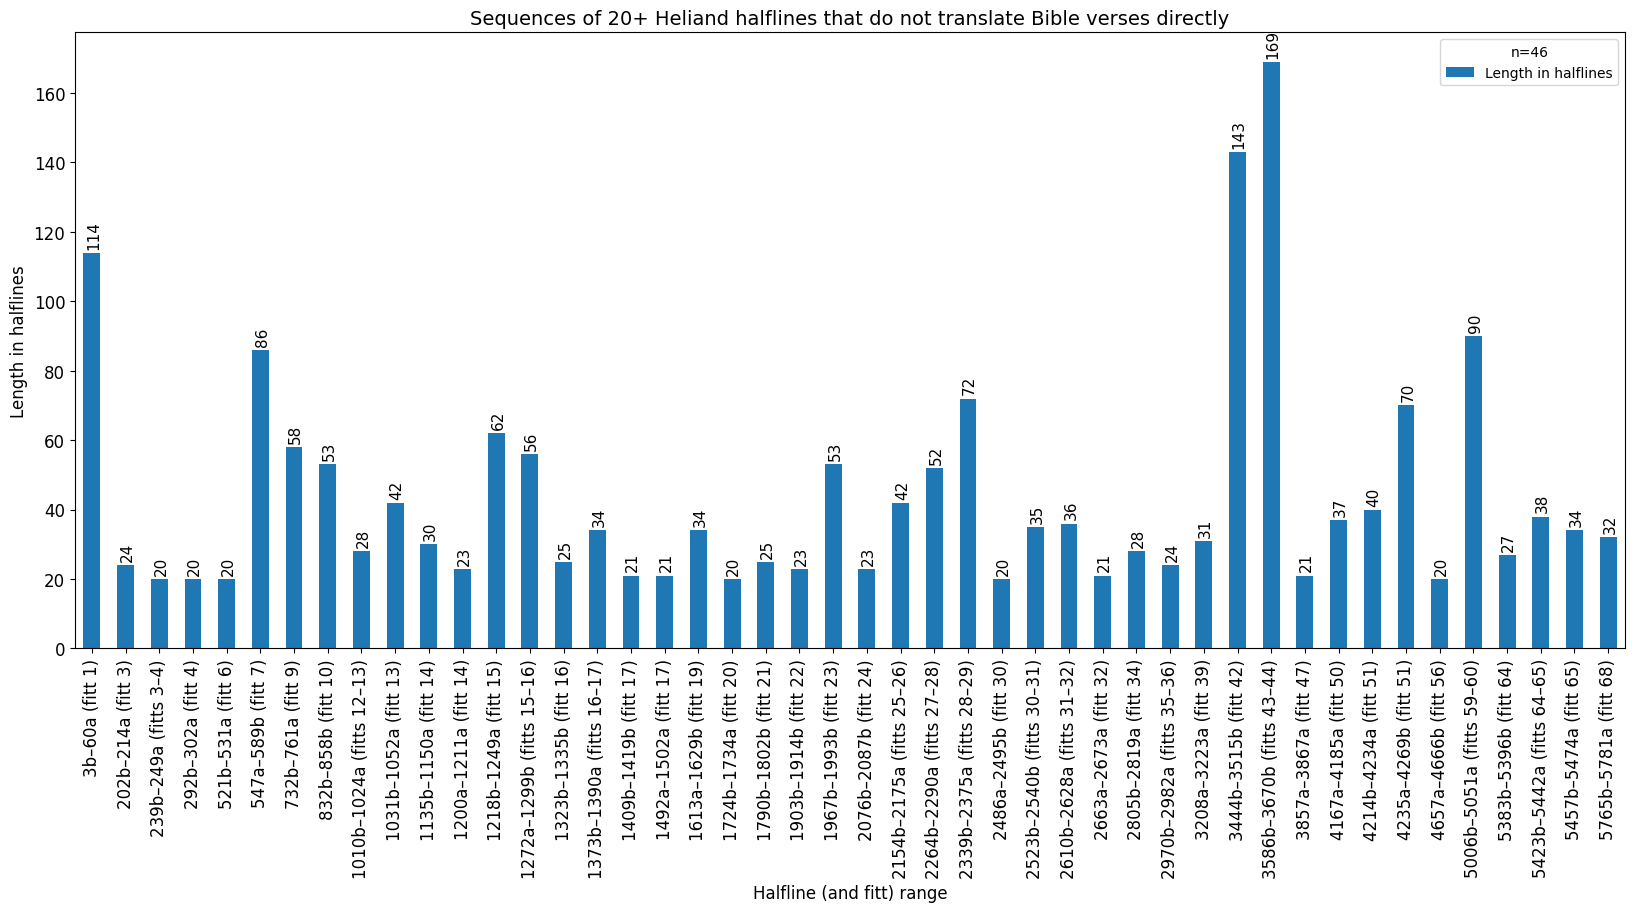

In [5]:
hist = df_long_gaps.plot.bar(x='Range', y='Length in halflines', figsize=(20,8), fontsize='12')
plt.title('Sequences of 20+ Heliand halflines that do not translate Bible verses directly', fontsize='14')
plt.legend(title='n=' + str(len(df_long_gaps)), fontsize='10')
locs, labels = plt.xticks()
hist.set_xlabel('Halfline (and fitt) range', fontsize='12')
hist.set_ylabel('Length in halflines', fontsize='12')
long_gaps_plot = plt.xticks(ticks=locs, labels=[i + ' (' + identify_fitts(i) + ')' for i in df_long_gaps['Range']])
xlocs = [i for i in range(len(df_long_gaps))]
for i,v in enumerate(df_long_gaps['Length in halflines']):
    plt.text(xlocs[i] - 0.17, v + 2, str(v), rotation='vertical', fontsize='11')
plt.savefig(fname='long-gaps.svg', format='svg', bbox_inches='tight')


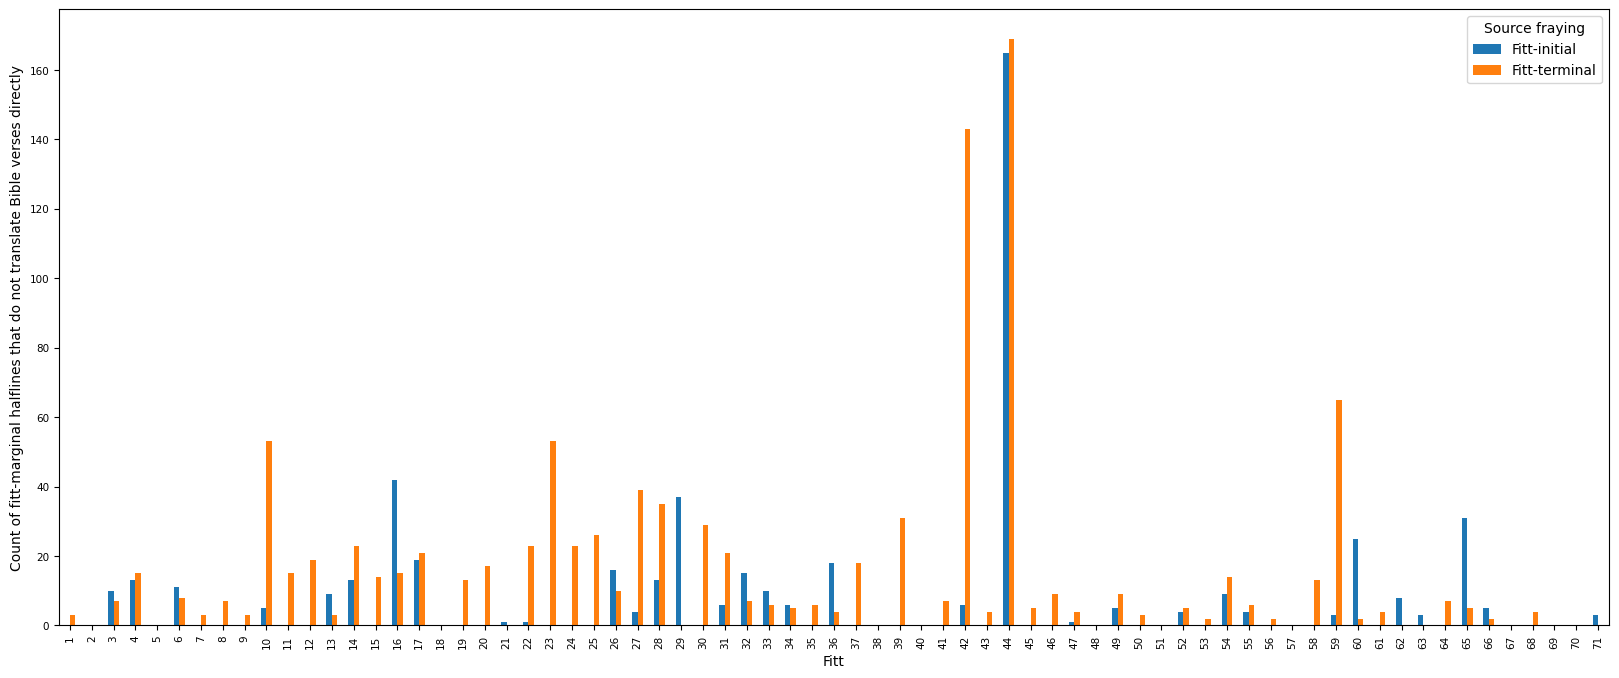

In [6]:
frays = get_frays()
df_frays = pd.DataFrame(frays)
frays_plot = df_frays.plot.bar(use_index='True',fontsize='7.5', figsize=(20,8))
frays_plot.legend(title='Source fraying', labels=['Fitt-initial', 'Fitt-terminal'])
frays_plot.set_xlabel('Fitt')
frays_plot.set_ylabel('Count of fitt-marginal halflines that do not translate Bible verses directly')
plt.savefig(fname='fraying.svg', format='svg', bbox_inches='tight')